Dataset shape: (200, 5)
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


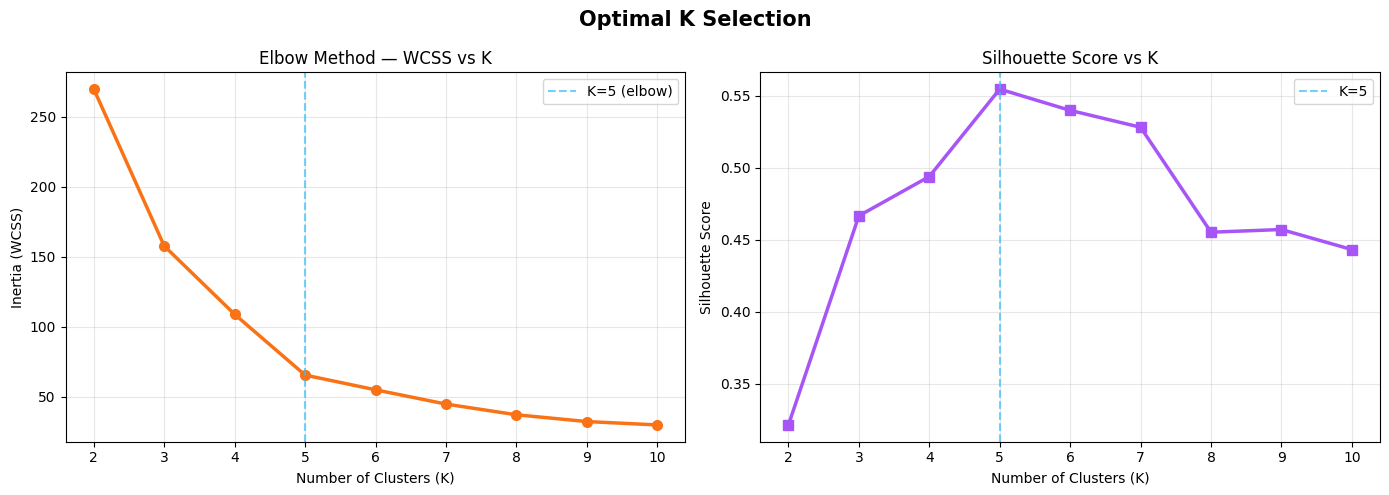

Saved: elbow_silhouette.png


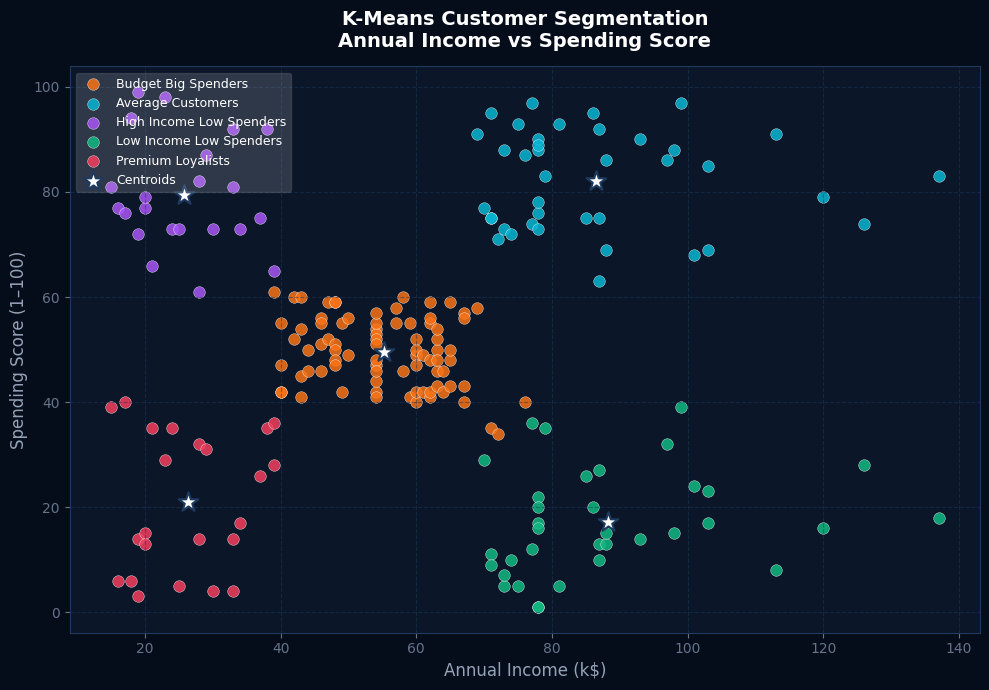


  CLUSTER SUMMARY STATISTICS
         Size  Avg_Age  Avg_Income  Avg_Score  Pct_Female                   Profile
Cluster                                                                            
0          81     42.7        55.3       49.5        59.3       Budget Big Spenders
1          39     32.7        86.5       82.1        53.8         Average Customers
2          22     25.3        25.7       79.4        59.1  High Income Low Spenders
3          35     41.1        88.2       17.1        45.7   Low Income Low Spenders
4          23     45.2        26.3       20.9        60.9         Premium Loyalists


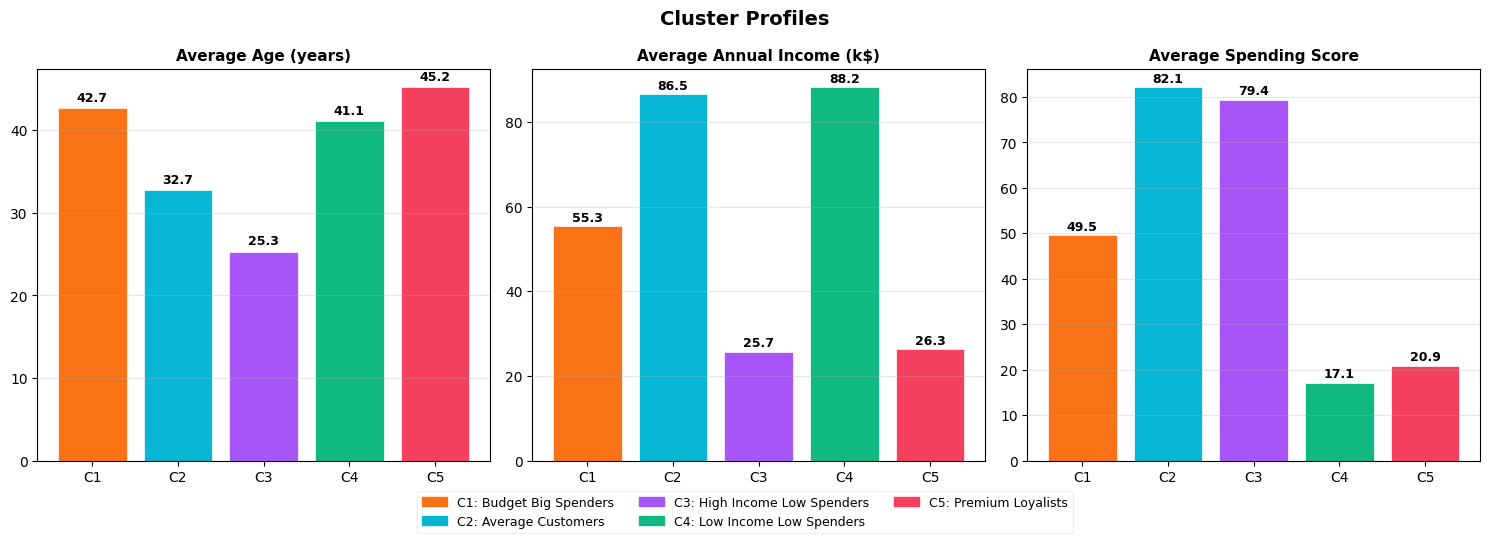

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Load Data
df = pd.read_csv("Mall_Customers.csv")
df.columns = ["CustomerID", "Gender", "Age", "Annual Income (k$)", "Spending Score (1-100)"]
print("Dataset shape:", df.shape)
print(df.head())

# Feature Selection & Scaling
X = df[["Annual Income (k$)", "Spending Score (1-100)"]].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method + Silhouette Score
inertias, silhouettes = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Optimal K Selection", fontsize=15, fontweight="bold")

axes[0].plot(K_range, inertias, "o-", color="#f97316", linewidth=2.5, markersize=7)
axes[0].axvline(5, color="#38bdf8", linestyle="--", alpha=0.7, label="K=5 (elbow)")
axes[0].set_title("Elbow Method — WCSS vs K")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia (WCSS)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(K_range, silhouettes, "s-", color="#a855f7", linewidth=2.5, markersize=7)
axes[1].axvline(5, color="#38bdf8", linestyle="--", alpha=0.7, label="K=5")
axes[1].set_title("Silhouette Score vs K")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("elbow_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: elbow_silhouette.png")

# Final Model — K=5
K = 5
km_final = KMeans(n_clusters=K, init="k-means++", n_init=10, random_state=42)
df["Cluster"] = km_final.fit_predict(X_scaled)

PALETTE = ["#f97316", "#06b6d4", "#a855f7", "#10b981", "#f43f5e"]
LABELS  = [
    "Budget Big Spenders",
    "Average Customers",
    "High Income Low Spenders",
    "Low Income Low Spenders",
    "Premium Loyalists",
]

# Cluster Scatter Plot
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor("#060d1a")
ax.set_facecolor("#0b1628")

for ci in range(K):
    mask = df["Cluster"] == ci
    ax.scatter(
        df.loc[mask, "Annual Income (k$)"],
        df.loc[mask, "Spending Score (1-100)"],
        c=PALETTE[ci], s=70, alpha=0.85, edgecolors="white", linewidths=0.3, label=LABELS[ci]
    )

# Plot centroids (inverse-transform to original scale)
centroids_orig = scaler.inverse_transform(km_final.cluster_centers_)
ax.scatter(
    centroids_orig[:, 0], centroids_orig[:, 1],
    c="white", s=220, marker="*", zorder=5, edgecolors="#1e3a5f", linewidths=1.5, label="Centroids"
)

ax.set_title("K-Means Customer Segmentation\nAnnual Income vs Spending Score",
             color="white", fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Annual Income (k$)", color="#94a3b8", fontsize=12)
ax.set_ylabel("Spending Score (1–100)", color="#94a3b8", fontsize=12)
ax.tick_params(colors="#64748b")
for spine in ax.spines.values():
    spine.set_edgecolor("#1e3a5f")
ax.grid(color="#1e3a5f", linestyle="--", alpha=0.5)
ax.legend(loc="upper left", framealpha=0.15, labelcolor="white", fontsize=9)

plt.tight_layout()
plt.savefig("clusters_scatter.png", dpi=150, bbox_inches="tight")
plt.show()


# Cluster Summary Stats
print("\n" + "="*60)
print("  CLUSTER SUMMARY STATISTICS")
print("="*60)

summary = df.groupby("Cluster").agg(
    Size        = ("CustomerID",              "count"),
    Avg_Age     = ("Age",                     "mean"),
    Avg_Income  = ("Annual Income (k$)",      "mean"),
    Avg_Score   = ("Spending Score (1-100)",  "mean"),
    Pct_Female  = ("Gender", lambda x: (x == "Female").mean() * 100),
).round(1)

summary["Profile"] = LABELS
print(summary.to_string())

# Cluster Distribution Bar Chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Cluster Profiles", fontsize=14, fontweight="bold")

metrics = [
    ("Avg_Age",    "Average Age (years)"),
    ("Avg_Income", "Average Annual Income (k$)"),
    ("Avg_Score",  "Average Spending Score"),
]

for ax, (col, title) in zip(axes, metrics):
    bars = ax.bar(range(K), summary[col], color=PALETTE, edgecolor="white", linewidth=0.5)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xticks(range(K))
    ax.set_xticklabels([f"C{i+1}" for i in range(K)], fontsize=10)
    ax.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, summary[col]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{val:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

patches = [mpatches.Patch(color=PALETTE[i], label=f"C{i+1}: {LABELS[i]}") for i in range(K)]
fig.legend(handles=patches, loc="lower center", ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.08), framealpha=0.3)

plt.tight_layout()
plt.savefig("cluster_profiles.png", dpi=150, bbox_inches="tight")
plt.show()


